In [21]:
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
#Loading the CSV

users_df = pd.read_csv('users.csv')
transactions_df = pd.read_csv('transactions.csv')
engagement_df = pd.read_csv('engagement_logs.csv')

In [7]:
#Quick look at the data 
print("USERS:", users_df.shape)
print(users_df.head())
print(users_df.dtypes)

print("\nTRANSACTIONS:", transactions_df.shape)
print(transactions_df.head())
print(transactions_df.dtypes)

print("\nENGAGEMENT:", engagement_df.shape)
print(engagement_df.head())
print(engagement_df.dtypes)

USERS: (41401, 7)
   user_id signup_date country  age gender platform acquisition_channel
0  U000001  2023-01-01      JP   21      F      iOS         paid_social
1  U000002  2023-01-01      HK   28      M  Android      email_campaign
2  U000003  2023-01-01      SG   50      M      Web         paid_search
3  U000004  2023-01-01      MY   37      M  Android      email_campaign
4  U000005  2023-01-01      TW   30      F  Android             organic
user_id                object
signup_date            object
country                object
age                     int64
gender                 object
platform               object
acquisition_channel    object
dtype: object

TRANSACTIONS: (124265, 9)
  transaction_id  user_id transaction_date              plan  amount  \
0      T00000001  U000001       2023-01-01  monthly_standard    9.99   
1      T00000002  U000002       2023-01-01  monthly_standard    9.99   
2      T00000003  U000003       2023-01-01  monthly_standard    9.99   
3      T000

In [8]:
#since the date is in object datatyp, converting it to datetime

users_df['signup_date'] = pd.to_datetime(users_df['signup_date'])
transactions_df['transaction_date'] = pd.to_datetime(transactions_df['transaction_date'])
engagement_df['log_date'] = pd.to_datetime(engagement_df['log_date'])

# Exploratory Data Analysis

<AxesSubplot: title={'center': 'New signups per month'}, xlabel='signup_date'>

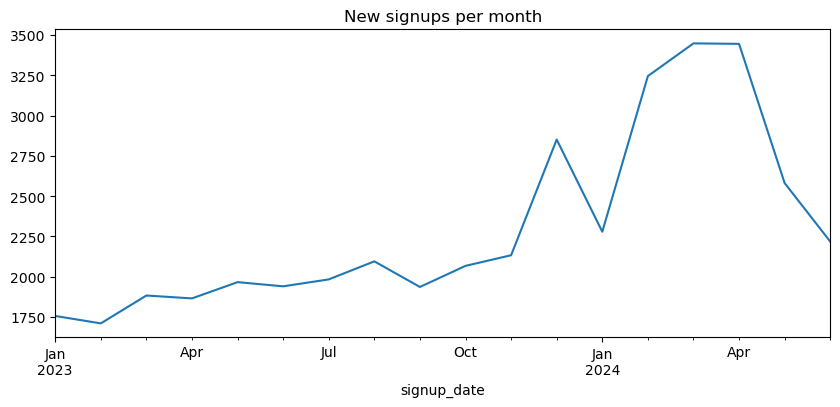

In [9]:
#Signup volume over time
users_df.groupby(users_df['signup_date'].dt.to_period('M')).size().plot(
    figsize=(10, 4), title='New signups per month'
)

There is a bump in signups starting around February 2024.

In [12]:
# Plan distribution
#Of all the users' first-time transactions, what proportion went to each plan
first_transactions = transactions_df[~transactions_df['is_renewal']]
plan_mix = first_transactions['plan'].value_counts(normalize=True)
print(plan_mix)

monthly_standard    0.554214
annual_standard     0.205792
monthly_premium     0.133547
trial_7day          0.106447
Name: plan, dtype: float64


55% of new signups picked monthly_standard,   
20% picked annual_standard,   
10% went for trial

In [11]:
# Channel distribution
users_df['acquisition_channel'].value_counts(normalize=True)

organic           0.353011
paid_social       0.261008
referral          0.173402
paid_search       0.144368
email_campaign    0.068211
Name: acquisition_channel, dtype: float64

Across all signups from Jan 2023 to Jun 2024:

***35% came through organic***  
26% through paid_social  
17% referral  
14% paid_search  
7% email_campaign  

That looks reasonable. Organic is the biggest channel, paid is meaningful but not dominant.

In [25]:
# The channel mix -  how it changed over time.
groupby_result = users_df.groupby(['cohort_month', 'acquisition_channel']).size()
print(groupby_result.head(10))

unstacked = groupby_result.unstack(fill_value=0)
print(unstacked.head())

row_totals = unstacked.sum(axis=1)
print(row_totals.head())

mix = unstacked.div(row_totals, axis=0)
print(mix.head().round(3))

cohort_month  acquisition_channel
2023-01       email_campaign         145
              organic                694
              paid_search            286
              paid_social            316
              referral               315
2023-02       email_campaign         114
              organic                631
              paid_search            277
              paid_social            332
              referral               356
dtype: int64
acquisition_channel  email_campaign  organic  paid_search  paid_social  \
cohort_month                                                             
2023-01                         145      694          286          316   
2023-02                         114      631          277          332   
2023-03                         129      710          316          369   
2023-04                         118      735          271          347   
2023-05                         142      788          290          332   

acquisition_channel  ref

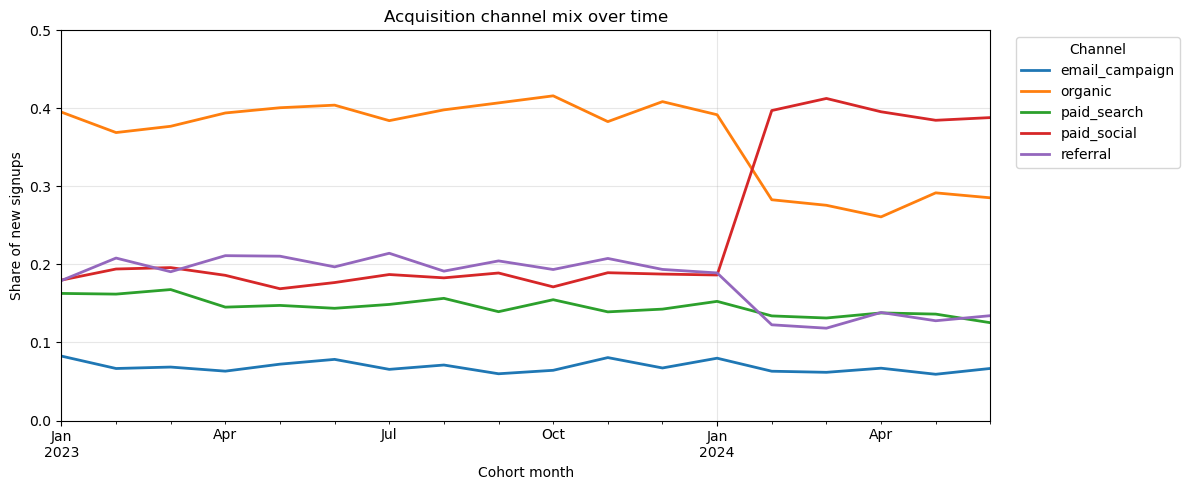

In [27]:
#visualisating acquisition channel over time

channel_mix.plot.line(figsize=(12, 5), linewidth=2)
plt.title('Acquisition channel mix over time')
plt.ylabel('Share of new signups')
plt.xlabel('Cohort month')
plt.legend(title='Channel', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(0, 0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

channel mix is roughly stable through 2023, then paid_social rises sharply from early 2024 while organic declines.

## Observation 1 :  Paid_social grew from ~20 % to ~40% starting February 2024;   
## Organic dropped correspondingly

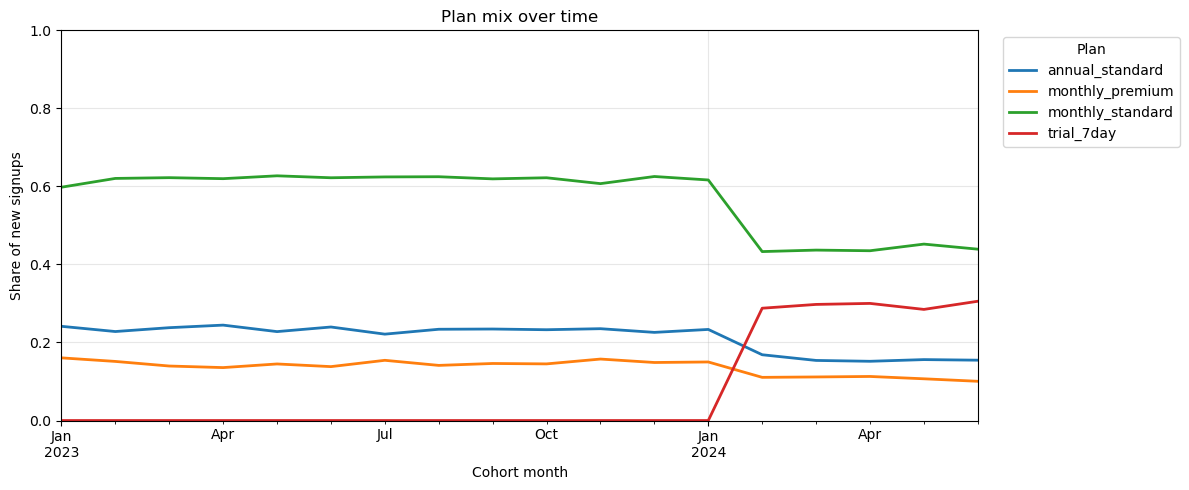

In [30]:
#Since we saw channel mix change over time , I want to see if its similar trend for transactions

transactions_df['transaction_date'] = pd.to_datetime(transactions_df['transaction_date'])

# First transactions only (one row per user)
first_transactions = transactions_df[~transactions_df['is_renewal']].copy()
first_transactions['cohort_month'] = first_transactions['transaction_date'].dt.to_period('M')

# Plan mix over time
plan_by_month = (
    first_transactions.groupby(['cohort_month', 'plan'])
    .size()
    .unstack(fill_value=0)
)
plan_mix = plan_by_month.div(plan_by_month.sum(axis=1), axis=0)

# Visualise
plan_mix.plot.line(figsize=(12, 5), linewidth=2)
plt.title('Plan mix over time')
plt.ylabel('Share of new signups')
plt.xlabel('Cohort month')
plt.legend(title='Plan', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Observation 2 : New plan trial 7day appeared in February 2024 at ~30% of signups.
## Monthly standard dropped from ~62% to ~30%

In [33]:
# Since I see a trend in paid social and a trial plan signups both in feb 2024, I wanna check if they are linked 

# Get each user's first plan
first_plans = first_transactions.set_index('user_id')['plan']
users_df['first_plan'] = users_df['user_id'].map(first_plans)

# Pre and post Feb 2024
cutoff = pd.Period('2024-02', 'M')
pre_feb = users_df[users_df['cohort_month'] < cutoff]
post_feb = users_df[users_df['cohort_month'] >= cutoff] 

# Which channels brought in which plans, before and after?
print("PRE-Feb 2024 — what plan did each channel's users pick?")
print(pd.crosstab(pre_feb['acquisition_channel'], pre_feb['first_plan'], normalize='index').round(3))

print("\nPOST-Feb 2024 — what plan did each channel's users pick?")
print(pd.crosstab(post_feb['acquisition_channel'], post_feb['first_plan'], normalize='index').round(3))

PRE-Feb 2024 — what plan did each channel's users pick?
first_plan           annual_standard  monthly_premium  monthly_standard
acquisition_channel                                                    
email_campaign                 0.214            0.158             0.628
organic                        0.235            0.148             0.617
paid_search                    0.235            0.150             0.616
paid_social                    0.221            0.154             0.625
referral                       0.246            0.135             0.619

POST-Feb 2024 — what plan did each channel's users pick?
first_plan           annual_standard  monthly_premium  monthly_standard  \
acquisition_channel                                                       
email_campaign                 0.216            0.121             0.540   
organic                        0.206            0.130             0.546   
paid_search                    0.147            0.101             0.459   
paid_so

## Before February 2024:
Every channel sent 60-63% of users to monthly_standard, 21-25% to annual_standard, 14-16% to monthly_premium.  
The mix was nearly identical across channels.   
Acquisition channel didn't really determine plan.

# After February 2024:  

The mix is now wildly different by channel. Specifically, the trial_7day column:

email_campaign : 12.3%  
organic : 11.8%  
referral : 10.2%  
paid_search : 29.4%  
paid_social : 50.9%   
  
Paid_social is sending nearly 50% of its users to the new trial plan.  
Paid_search is sending nearly a third.   
Organic, referral, and email are sending only ~10-12%.  

# Observation 3:  
1. The new trial plan is being pushed priamrily through paid social especially .  
2. Organic sourced users still mostly picked the same plans they always did .
3. This is more of a acquisition strategy rather than a preference shift.


After February 2024, 51% of paid_social acquisitions chose trial_7day, vs. only 12% from organic.   
Combined with the channel mix shift (paid_social grew from 18% to 40% of total signups), this is consistent with a paid_social campaign promoting the new trial plan as the primary acquisition lever

# What we have learnt so far  
1. A new plan (Trial 7 day) launched in February 2024 going from 0% to a major share of signups.  
2. The channel mix shifted : paid social gre while organic shrank    
3. There is a correlation - Paid social was the main acquistion channel for the new plan

# What to check ?   
1. Do trial_7day users retain at the same rate as other plans?  
2. Do paid_social users retain at the same rate as other channels?    
3. Is the headline retention drop being driven by these new users, or is it across the board?


# Defining Retention  
I am defining a user is retained if they made a second transaction within 60 days of their first transaction.  
- 60 days : This would cover monthly standard , captures 7 day trial conversions and gives a comparable window across plan types  
- Trade off: Annual standard users will show as not reatined because their renewal cycle is 365 days. I will exclude them .  
- Users who signed up in the last 60 days havent had time to be tested by this metric. I will exclude them from analysis 

In [48]:
# Get each user's first transaction date
first_txn_dates = (
    transactions_df[~transactions_df['is_renewal']]
    .set_index('user_id')['transaction_date']
)  

# Get each user's earliest renewal (second) transaction date, if any
renewal_dates = (
    transactions_df[transactions_df['is_renewal']]
    .groupby('user_id')['transaction_date']
    .min()
)  

# Combine
users_df['first_txn_date'] = users_df['user_id'].map(first_txn_dates)
users_df['first_renewal_date'] = users_df['user_id'].map(renewal_dates)   

# Days between first transaction and first renewal
users_df['days_to_renewal'] = (
    users_df['first_renewal_date'] - users_df['first_txn_date']
).dt.days

# Retained = had a renewal within 60 days
users_df['retained_60d'] = users_df['days_to_renewal'] <= 60
users_df['retained_60d'] = users_df['retained_60d'].fillna(False)

# Quick sanity check
print(f"Overall retention rate: {users_df['retained_60d'].mean():.1%}")
print(f"Users with no renewal at all: {users_df['days_to_renewal'].isna().sum():,}")  
print("\n")  

print(users_df.head(10))

Overall retention rate: 51.7%
Users with no renewal at all: 17,826


   user_id signup_date country  age gender platform acquisition_channel  \
0  U000001  2023-01-01      JP   21      F      iOS         paid_social   
1  U000002  2023-01-01      HK   28      M  Android      email_campaign   
2  U000003  2023-01-01      SG   50      M      Web         paid_search   
3  U000004  2023-01-01      MY   37      M  Android      email_campaign   
4  U000005  2023-01-01      TW   30      F  Android             organic   
5  U000006  2023-01-01      HK   16      M      iOS            referral   
6  U000007  2023-01-01      TW   35      M  Android      email_campaign   
7  U000008  2023-01-01      ID   31      F  Android         paid_social   
8  U000009  2023-01-01      MY   47      F      iOS             organic   
9  U000010  2023-01-01      ID   46      M      iOS         paid_search   

  cohort_month        first_plan first_txn_date first_renewal_date  \
0      2023-01  monthly_standard   

In [42]:
# Distribution of plan durations among first transactions
print("Plan durations (first transactions):")
print(first_transactions.groupby('plan')['duration_days'].first())

# How long do users actually take to renew, in the data?
renewals_with_first = pd.merge(
    transactions_df[transactions_df['is_renewal']].groupby('user_id')['transaction_date'].min().reset_index(),
    transactions_df[~transactions_df['is_renewal']][['user_id', 'transaction_date']],
    on='user_id', suffixes=('_renewal', '_first')
)
renewals_with_first['days'] = (
    renewals_with_first['transaction_date_renewal'] - renewals_with_first['transaction_date_first']
).dt.days
print("\nDays from first transaction to first renewal (distribution):")
print(renewals_with_first['days'].describe())
print("\nPercentiles:")
print(renewals_with_first['days'].quantile([0.1, 0.25, 0.5, 0.75, 0.9]))

Plan durations (first transactions):
plan
annual_standard     365
monthly_premium      30
monthly_standard     30
trial_7day            7
Name: duration_days, dtype: int64

Days from first transaction to first renewal (distribution):
count    23575.000000
mean        60.644581
std         97.402318
min          7.000000
25%         30.000000
50%         30.000000
75%         30.000000
max        365.000000
Name: days, dtype: float64

Percentiles:
0.10    30.0
0.25    30.0
0.50    30.0
0.75    30.0
0.90    30.0
Name: days, dtype: float64


In [50]:
#Filtering out annual users  

users_non_annual = users_df[users_df['first_plan'] != 'annual_standard'].copy()

# Get each user's first transaction and first renewal dates
first_txn_dates = (
    transactions_df[~transactions_df['is_renewal']]
    .set_index('user_id')['transaction_date']
)
renewal_dates = (
    transactions_df[transactions_df['is_renewal']]
    .groupby('user_id')['transaction_date']
    .min()
)

users_non_annual['first_txn_date'] = users_non_annual['user_id'].map(first_txn_dates)
users_non_annual['first_renewal_date'] = users_non_annual['user_id'].map(renewal_dates)

# Days to renewal
users_non_annual['days_to_renewal'] = (
    users_non_annual['first_renewal_date'] - users_non_annual['first_txn_date']
).dt.days

# Retained = renewed within 60 days
users_non_annual['retained_60d'] = (users_non_annual['days_to_renewal'] <= 60).fillna(False)

# Apply right-censoring: users need at least 60 days of observation time
latest_date = transactions_df['transaction_date'].max()
analysis_cutoff = latest_date - pd.Timedelta(days=60)

users_eligible = users_non_annual[users_non_annual['first_txn_date'] <= analysis_cutoff].copy()

# Headline number
print(f"Latest date in data: {latest_date.date()}")
print(f"Cutoff for inclusion: {analysis_cutoff.date()}")
print(f"Total non-annual users: {len(users_non_annual):,}")
print(f"Eligible (had 60 days to be tested): {len(users_eligible):,}")
print(f"\nOverall 60-day retention rate: {users_eligible['retained_60d'].mean():.1%}")

Latest date in data: 2024-06-30
Cutoff for inclusion: 2024-05-01
Total non-annual users: 32,881
Eligible (had 60 days to be tested): 28,900

Overall 60-day retention rate: 69.8%


              retention_rate  cohort_size
cohort_month                             
2023-01                0.783         1332
2023-02                0.766         1320
2023-03                0.758         1435
2023-04                0.769         1409
2023-05                0.783         1518
2023-06                0.776         1475
2023-07                0.754         1544
2023-08                0.768         1605
2023-09                0.772         1482
2023-10                0.781         1586
2023-11                0.771         1631
2023-12                0.776         2207
2024-01                0.772         1747
2024-02                0.523         2698
2024-03                0.525         2917
2024-04                0.525         2922
2024-05                0.611           72


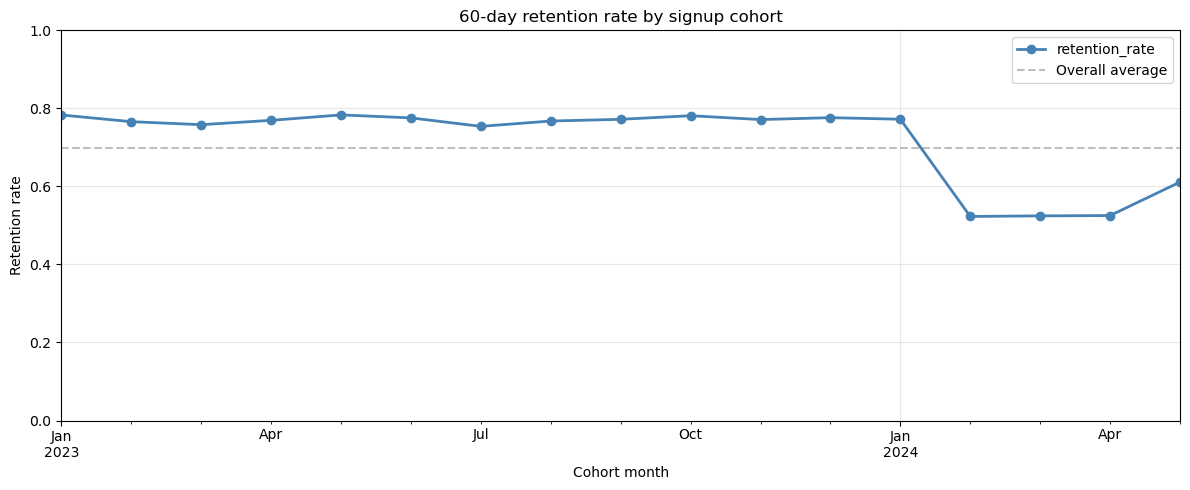

In [53]:

# Add cohort month
users_eligible['cohort_month'] = users_eligible['first_txn_date'].dt.to_period('M')

# Retention by cohort, with cohort size for context
cohort_retention = users_eligible.groupby('cohort_month').agg(
    retention_rate=('retained_60d', 'mean'),
    cohort_size=('retained_60d', 'count')
)

print(cohort_retention.round(3)) 

fig, ax = plt.subplots(figsize=(12, 5))
cohort_retention['retention_rate'].plot(
    ax=ax, marker='o', linewidth=2, color='steelblue'
)
ax.set_title('60-day retention rate by signup cohort')
ax.set_ylabel('Retention rate')
ax.set_xlabel('Cohort month')
ax.set_ylim(0, 1)
ax.axhline(y=users_eligible['retained_60d'].mean(), color='gray', linestyle='--', alpha=0.5, label='Overall average')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Observation 4: 
Between January 2023 and January 2024, 60-day retention sat in a tight band of 75-78% across every cohort.  
In February 2024, it dropped sharply to 52.3% and stayed at that level till April.  
One thing to note here is that at the same time, monthly signup volume nearly doubled from ~1,500/month in 2023 to ~2,900/month in early 2024.  
  
We were not just losing existing users byt were attracting new lower quality users.    


# What we have learnt so far  
 
New trial plan launched (cheaper offer attracts more people)  
Paid_social grew (paid acquisition scales volume)  
Retention dropped (those new users behave worse)

# What to check next ? 
is the retention drop driven by the new trial users, or is it across the board?

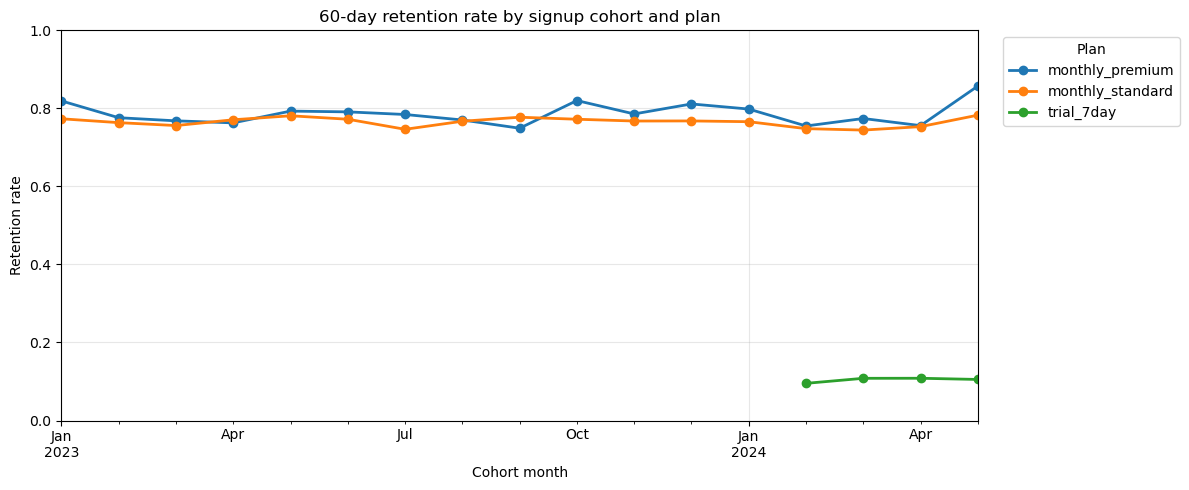

In [60]:
# Does monthly_standard retention stay at ~77% throughout 2024, while trial_7day drags the average down? 
# Retention by cohort_month and plan
retention_by_plan_cohort = (
    users_eligible
    .groupby(['cohort_month', 'first_plan'])
    ['retained_60d']
    .agg(['mean', 'count'])
    .round(3)
)

# Reshape from long to wide: rows are months, columns are plans
retention_pivot = (
    users_eligible
    .groupby(['cohort_month', 'first_plan'])['retained_60d']
    .mean()
    .unstack()
)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
retention_pivot.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('60-day retention rate by signup cohort and plan')
ax.set_ylabel('Retention rate')
ax.set_xlabel('Cohort month')
ax.set_ylim(0, 1)
ax.legend(title='Plan', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Observations 5  
Monthly_standard retention stayed flat throughout 2023 and 2024, sitting in the
  same ~75-80% band that it has all year. 
  
- Existing monthly users behave exactly the same as they always have.
- Monthly_premium also stayed flat
- Trial_7day appears in February 2024 and retains far below  the other plans.  

why does the trial_7day plan retain so poorly,and is that acceptable?

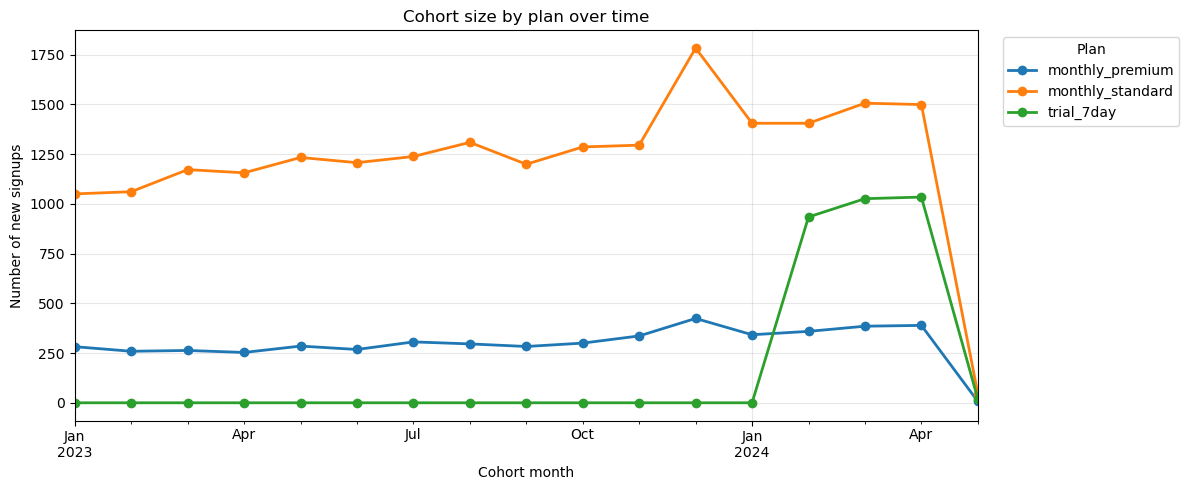

In [58]:
# Cohort sizes by plan
size_pivot = (
    users_eligible
    .groupby(['cohort_month', 'first_plan'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
size_pivot.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Cohort size by plan over time')
ax.set_ylabel('Number of new signups')
ax.set_xlabel('Cohort month')
ax.legend(title='Plan', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Observations 6    
- From February 2024 onwards, **trial_7day brought in ~1,000 new users per month**,comparable in volume to monthly_standard.
- Total signup volume nearly doubled in that period, from ~1,500/month in 2023 to ~2,900/month in 2024.  
 
So the trial isn't a small experiment. It's a major acquisition channel. Even if the
retention is lower, the absolute number of retained users from trial_7day is meaningful.  

within the trial cohort, do *all* trial users retain at low rate, or does retention vary sharply by where the user came from?  
If paid_social trial users behave very differently from organic trial users, that points to an even more specific problem.

In [62]:
# Checking if retention varies by channel within trial users   
# Restrict to trial_7day users only
trial_users = users_eligible[users_eligible['first_plan'] == 'trial_7day'].copy()

# Retention by channel for trial users
trial_retention_by_channel = (
    trial_users.groupby('acquisition_channel')['retained_60d']
    .agg(['mean', 'count'])
    .round(3)
    .sort_values('mean', ascending=False)
)

print(f"Total trial users analysed: {len(trial_users):,}")
print(f"Overall trial retention: {trial_users['retained_60d'].mean():.1%}\n")
print(trial_retention_by_channel)

Total trial users analysed: 3,013
Overall trial retention: 10.4%

                      mean  count
acquisition_channel              
email_campaign       0.133     75
paid_search          0.125    401
organic              0.114    306
paid_social          0.099   2105
referral             0.087    126


Trial retention is 10.4% across the board.  
Roughly 9 out of 10 trial users never come back.    
Trial users behave badly regardless of where they came from  .     
Trial plan is the issue not the channel mix  
Paid social is bringing in the largest volume of trial users and trial suers in general retai poorly.

# Observation 7   
The trial plan itself isn't working for retention, regardless of where users come from.   
The product team needs to either fix the trial experience, change the trial economics, or accept the trial as a low-retention top-of-funnel tool and justify it on different metrics  

One point to note, referral customers has the lowest retention which is surpising becuse they usually are the highest-quality cohort because they came in via word-of-mouth.  
  
The referral sample is small (n=126) and this is noise  
The trial plan is so bad that even referral users who would normally retain well fall through

# What we have learnt so far?  

Overall  retention dropped from ~77% to ~52% in February 2024 (cohort retention chart)  
Existing plans (monthly_standard, monthly_premium) retention stayed flat . It's not a product quality issue (cohort × plan chart)  
The drop is driven by trial_7day at 10.4% retention, which is a uniform problem across channels (this latest table)

# What to check?  
what does engagement look like for trial users vs others?   
Are they actually using the product, or signing up and disappearing?

In [66]:
# Build a per-user engagement summary
engagement_df['log_date'] = pd.to_datetime(engagement_df['log_date'])

# Join engagement logs with each user's signup date
engagement_with_signup = engagement_df.merge(
    users_eligible[['user_id', 'first_txn_date', 'first_plan']],
    on='user_id',
    how='inner'  # only keep users who are in our eligible set
)

# Compute days since signup for each log entry
engagement_with_signup['days_since_signup'] = (
    engagement_with_signup['log_date'] - engagement_with_signup['first_txn_date']
).dt.days

# Filter to week-1 activity only (days 0-6)
week1 = engagement_with_signup[
    (engagement_with_signup['days_since_signup'] >= 0) &
    (engagement_with_signup['days_since_signup'] <= 6)
]

# Aggregate to one row per user
week1_summary = week1.groupby('user_id').agg(
    active_days_w1=('log_date', 'nunique'),
    total_songs_w1=('songs_played', 'sum'),
    total_seconds_w1=('seconds_played', 'sum'),
    unique_artists_w1=('unique_artists', 'sum'),
).reset_index()

# Merge back into users_eligible
users_eligible = users_eligible.merge(week1_summary, on='user_id', how='left')

# Users with no logs in week 1 -  fill with 0
for col in ['active_days_w1', 'total_songs_w1', 'total_seconds_w1', 'unique_artists_w1']:
    users_eligible[col] = users_eligible[col].fillna(0).astype(int)

print(users_eligible[['user_id', 'first_plan', 'active_days_w1',
                       'total_songs_w1', 'retained_60d']].head(10))

   user_id        first_plan  active_days_w1  total_songs_w1  retained_60d
0  U000001  monthly_standard               3              48         False
1  U000002  monthly_standard               4              61         False
2  U000003  monthly_standard               0               0          True
3  U000004  monthly_standard               4             180         False
4  U000005  monthly_standard               2              20         False
5  U000006  monthly_standard               1              14          True
6  U000007  monthly_standard               4              93          True
7  U000009   monthly_premium               2              13          True
8  U000010  monthly_standard               3              43          True
9  U000012  monthly_standard               4              76          True


In [69]:
# Compare engagement across plans
engagement_by_plan = (
users_eligible.groupby('first_plan')[['active_days_w1', 'total_songs_w1', 'total_seconds_w1']]
    .agg(['mean', 'median'])
    .round(1)
)

print(engagement_by_plan)

                 active_days_w1        total_songs_w1        total_seconds_w1  \
                           mean median           mean median             mean   
first_plan                                                                      
monthly_premium             2.3    2.0           37.8   26.0           6771.1   
monthly_standard            2.2    2.0           35.3   23.0           6363.1   
trial_7day                  1.0    1.0           16.7    7.0           3028.7   

                          
                  median  
first_plan                
monthly_premium   4567.0  
monthly_standard  4152.0  
trial_7day        1109.0  


# Observations 8    

1. Trial users engage about half as much as paying users    
2. However Trial users do not engage : They are trying it but not finding enough reason to stay   
3. Monthly_standard and monthly_premium look nearly identical :- Paid users behave like paid users regardless of tier. The break is between paid and trial, not between premium and standard.  

90% of trial users don't renew (10.4% retention)
Those who don't renew did engage with the product, just much less than monthly users
They spent ~18 minutes total over 7 days - that's basically one short listening session  

Trial users sign up, give the product a try (probably one short session), don't get hooked, and leave.

In [70]:
# Within trial users, does engagement predict retention?  

# Restrict to trial users
trial_users = users_eligible[users_eligible['first_plan'] == 'trial_7day'].copy()

# Bucket by week-1 active days
def engagement_bucket(days):
    if days == 0:
        return '0 days (no activity)'
    elif days <= 2:
        return '1-2 days (low)'
    elif days <= 4:
        return '3-4 days (medium)'
    else:
        return '5-7 days (high)'

trial_users['engagement_bucket'] = trial_users['active_days_w1'].apply(engagement_bucket)

# Retention by engagement bucket
trial_retention_by_engagement = (
    trial_users
    .groupby('engagement_bucket')['retained_60d']
    .agg(['mean', 'count'])
    .round(3)
    .reindex(['0 days (no activity)', '1-2 days (low)', '3-4 days (medium)', '5-7 days (high)'])
)

print(trial_retention_by_engagement)

                       mean  count
engagement_bucket                 
0 days (no activity)  0.107   1276
1-2 days (low)        0.100   1369
3-4 days (medium)     0.119    312
5-7 days (high)       0.071     56


# Observations 9   
1. Engagement does not predict retention for trial users - All buckets sit within 7-12% . Even the trial users who used the product 5-7 days a week retain at 7.1%.  
2. Only 56 users in high engagment bucket . 
3. No activity bucket - Only 42% of trial signups never opened the product at all within their first week   


The trial offer is attracting a fundamentally different kind of user i.e. someone who's evaluating 'is this worth $9.99/month?' rather than 'do I like this product?'

42% don't even open the product : they signed up for the cheap deal, not because they wanted music  
Retention is uniform across engagement levels : trying the product more doesn't change the buying decision  
Even the engaged users (56 of them) don't convert : they liked it enough to listen but not enough to pay $9.99  

In [72]:
#checking auto renew

# Get auto-renew status from each user's first transaction
first_txn_auto_renew = (
    transactions_df[~transactions_df['is_renewal']]
    .set_index('user_id')['auto_renew']
)
trial_users['auto_renew_at_signup'] = trial_users['user_id'].map(first_txn_auto_renew)

# Retention by auto-renew status
auto_renew_split = (
    trial_users
    .groupby('auto_renew_at_signup')['retained_60d']
    .agg(['mean', 'count'])
    .round(3)
)
print(auto_renew_split)

                       mean  count
auto_renew_at_signup              
False                 0.101   2708
True                  0.134    305


1. Auto-renew-on retains slightly better : but only by ~3 percentage points.   
I expected a much bigger gap. In most subscription products, auto-renew-on retains 2-5x better than auto-renew-off because passive renewers just keep paying. Here it's barely a difference.    

2. Auto-renew is mostly off for trial users. 2,708 of 3,013 trial users (90%) have auto-renew off. So even if switching the default fully closed the 3-point gap, the lift would be small  at best ~3 percentage points across the trial cohort, taking you from 10.4% to maybe 13%.

# Recommendations     

## 1. Run a unit economics view 
 1. CPA to acquire a trial user
 2. Expected revenue   
 
 If trial CPA exceeds expected LTV, the trial is unprofitable on direct economics. The company is paying to acquire users who don't pay back.  
 
## 2: Restructure the trial offer rather than the trial experience  

If the unit economics check out (or if the trial is justified for non-retention reasons like brand awareness), the data suggests the offer itself needs changing  .   
1. Switch Auto renew default to ON for the trial  it could be a quick win that requires no engineering effort . 
2. Test a different test structure - The 7-day, $0.99 trial is selecting for price-shoppers. Test alternatives that change the user mindset:  

A 30-day trial at the same low price (more time for habit formation)  
A first-month-discounted offer 4.99 first month, then 9.99)  converts the trial into a price-anchored monthly subscription rather than a 7-day evaluation  
A free trial gated on payment method capture (lower friction to start, opt-out at end)  



## 3:Reframe the trial as an acquisition tool, not a retention tool 

Even if trial retention stays at 10%, the trial isn't necessarily a failure .It depends on what the company is trying to achieve.  

-Brand awareness / top-of-funnel volume (get people through the door, even if they don't convert)
-Eventual upgrade path (a user who tried 6 months ago might convert now)
-Marketing attribution data (paid_social conversion data improves targeting over time)
 